In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))

from utils.common import config

In [2]:
# Sampling site coordinates (Mjøsa origin)
LAT_CENTER = config.LAT0  # 60.801146°N
LON_CENTER = config.LON0  # 10.705125°E

print(f"Sampling site center: {LAT_CENTER}°N, {LON_CENTER}°E")

Sampling site center: 60.801146°N, 10.705125°E


In [3]:
# Map extent (adjust these to zoom in/out)
extent_km = 5  # kilometers around center

# Convert km to degrees (approximate at this latitude)
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.radians(LAT_CENTER))

lat_span = extent_km / km_per_deg_lat
lon_span = extent_km / km_per_deg_lon

extent = [
    LON_CENTER - lon_span,  # left
    LON_CENTER + lon_span,  # right
    LAT_CENTER - lat_span,  # bottom
    LAT_CENTER + lat_span,  # top
]

print(f"Map extent: {extent_km} km around center")
print(f"Longitude: {extent[0]:.4f}°E to {extent[1]:.4f}°E")
print(f"Latitude: {extent[2]:.4f}°N to {extent[3]:.4f}°N")

Map extent: 5 km around center
Longitude: 10.6128°E to 10.7975°E
Latitude: 60.7561°N to 60.8462°N


## Style 1: Natural Earth - Physical Features Only

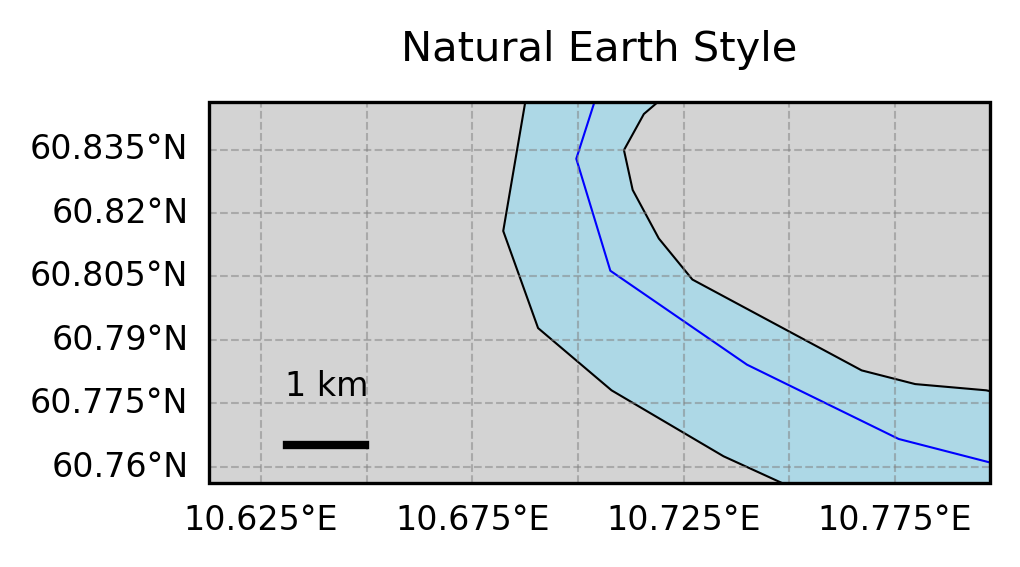

In [4]:
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add land and water features
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAKES, facecolor="lightblue", edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.5)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Add scale bar (approximate)
scale_km = 1  # 1 km scale bar
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.title("Natural Earth Style", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Style 2: High Resolution - Detailed Coastlines

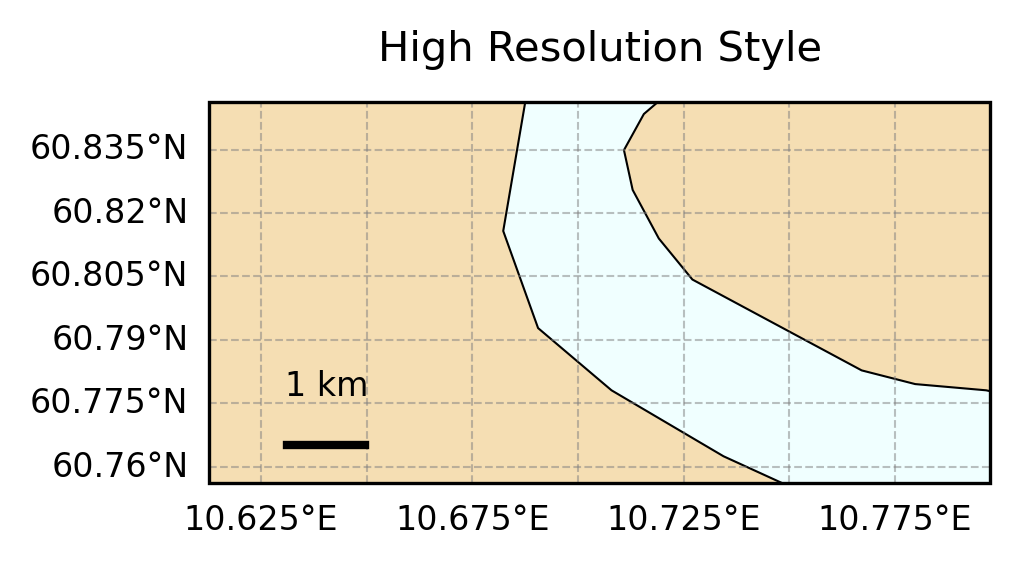

In [5]:
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# High resolution coastlines and borders
ax.coastlines(resolution="10m", linewidth=0.8, color="black")
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="wheat", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="azure")
ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="azure",
    edgecolor="black",
    linewidth=0.5,
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.title("High Resolution Style", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Style 3: Minimalist - Land/Water Only

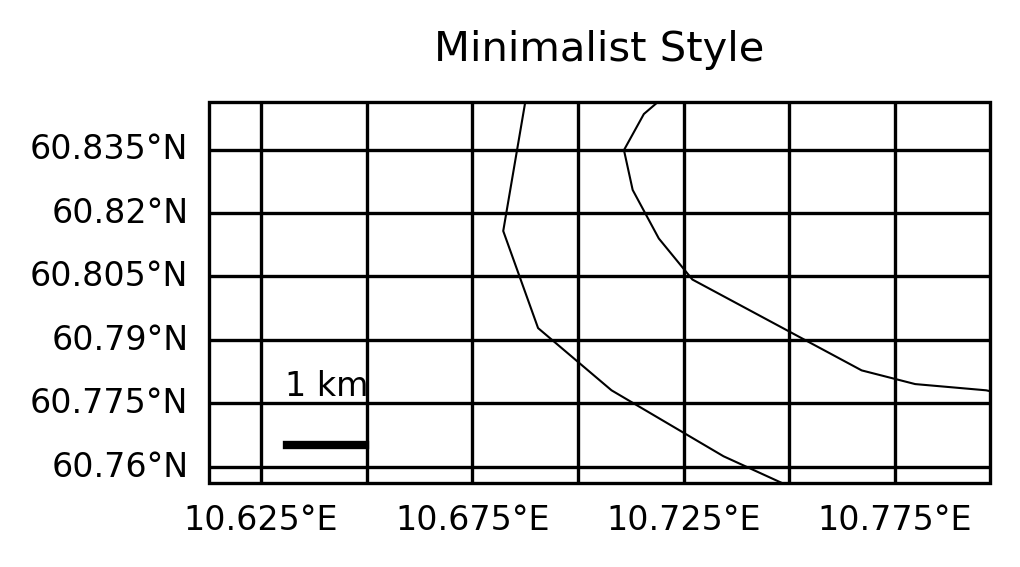

In [6]:
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Minimalist: just land and water
ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.LAKES, facecolor="white", edgecolor="black", linewidth=0.5)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.8, color="black", alpha=1.0, linestyle="-"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.title("Minimalist Style", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Adjust Map Extent
Change `extent_km` value and re-run the cells above to zoom in/out

In [7]:
# Try different zoom levels
for zoom_km in [2, 5, 10, 20]:
    lat_span = zoom_km / km_per_deg_lat
    lon_span = zoom_km / km_per_deg_lon

    test_extent = [
        LON_CENTER - lon_span,
        LON_CENTER + lon_span,
        LAT_CENTER - lat_span,
        LAT_CENTER + lat_span,
    ]

    print(f"\n{zoom_km} km extent:")
    print(f"  Lon: {test_extent[0]:.4f}°E to {test_extent[1]:.4f}°E")
    print(f"  Lat: {test_extent[2]:.4f}°N to {test_extent[3]:.4f}°N")


2 km extent:
  Lon: 10.6682°E to 10.7421°E
  Lat: 60.7831°N to 60.8192°N

5 km extent:
  Lon: 10.6128°E to 10.7975°E
  Lat: 60.7561°N to 60.8462°N

10 km extent:
  Lon: 10.5205°E to 10.8898°E
  Lat: 60.7111°N to 60.8912°N

20 km extent:
  Lon: 10.3358°E to 11.0745°E
  Lat: 60.6210°N to 60.9813°N


## Save Final Version
Once you've chosen your preferred style and extent

Saved: publication_map_natural_earth_5km.png


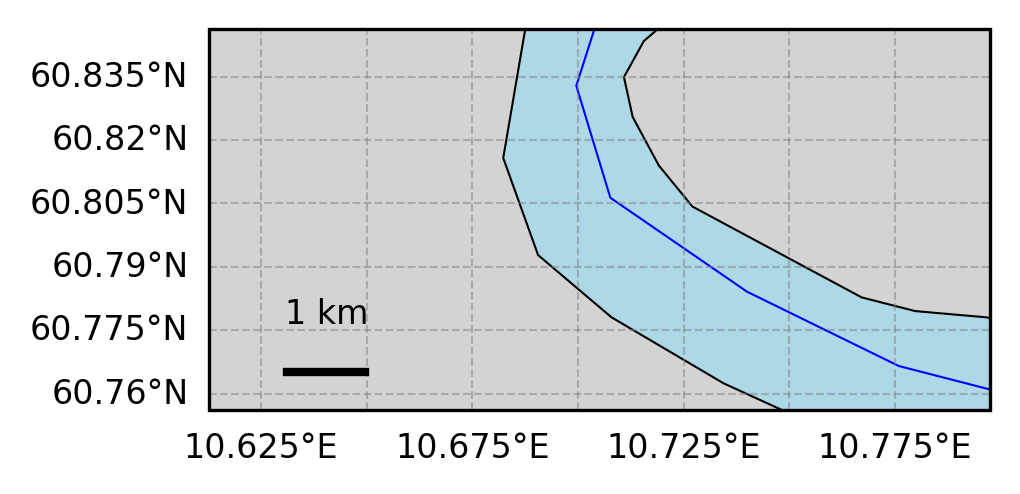

In [8]:
# Set your final parameters
FINAL_EXTENT_KM = 5  # Choose your zoom level
FINAL_STYLE = "natural_earth"  # 'natural_earth', 'high_res', or 'minimalist'
OUTPUT_FORMAT = "png"  # 'png', 'pdf', 'svg', 'tiff'
OUTPUT_DPI = 300

# Calculate extent
lat_span = FINAL_EXTENT_KM / km_per_deg_lat
lon_span = FINAL_EXTENT_KM / km_per_deg_lon
final_extent = [
    LON_CENTER - lon_span,
    LON_CENTER + lon_span,
    LAT_CENTER - lat_span,
    LAT_CENTER + lat_span,
]

# Create figure
fig = plt.figure(figsize=(3.5, 3.5), dpi=OUTPUT_DPI)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(final_extent, crs=ccrs.PlateCarree())

# Apply chosen style
if FINAL_STYLE == "natural_earth":
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(
        cfeature.LAKES, facecolor="lightblue", edgecolor="black", linewidth=0.5
    )
    ax.add_feature(cfeature.RIVERS, edgecolor="blue", linewidth=0.5)
elif FINAL_STYLE == "high_res":
    ax.coastlines(resolution="10m", linewidth=0.8, color="black")
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="wheat", edgecolor="none")
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="azure")
    ax.add_feature(
        cfeature.LAKES.with_scale("10m"),
        facecolor="azure",
        edgecolor="black",
        linewidth=0.5,
    )
elif FINAL_STYLE == "minimalist":
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="black", linewidth=0.8)
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.add_feature(cfeature.LAKES, facecolor="white", edgecolor="black", linewidth=0.5)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = final_extent[0] + 0.1 * (final_extent[1] - final_extent[0])
scale_y = final_extent[2] + 0.1 * (final_extent[3] - final_extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.01,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
)

plt.tight_layout()

# Save
output_file = f"publication_map_{FINAL_STYLE}_{FINAL_EXTENT_KM}km.{OUTPUT_FORMAT}"
plt.savefig(output_file, dpi=OUTPUT_DPI, bbox_inches="tight", facecolor="white")
print(f"Saved: {output_file}")
plt.show()

## High-Resolution Map with Real Basemap Tiles
Uses actual map tiles for detailed background

In [ ]:
import cartopy.io.img_tiles as cimgt

# Option 1: OpenStreetMap - most detailed
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = cimgt.OSM()
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map tiles at appropriate zoom level (higher = more detail)
# For 2x2 km area, zoom 15-16 is good
ax.add_image(tile_source, 15)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="white", alpha=0.8, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8, "color": "white"}
gl.ylabel_style = {"size": 8, "color": "white"}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar (white for visibility on map)
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    color="white",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.5),
)

plt.title("OpenStreetMap - High Detail", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

c:\conda_envs\my_env\lib\site-packages\cartopy\io\img_tiles.py:414: UserWarning: The Stamen styles are no longer served by Stamen and are now served by Stadia Maps. Please use the StadiaMapsTiles class instead.
  warnings.warn("The Stamen styles are no longer served by Stamen and "


<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errn

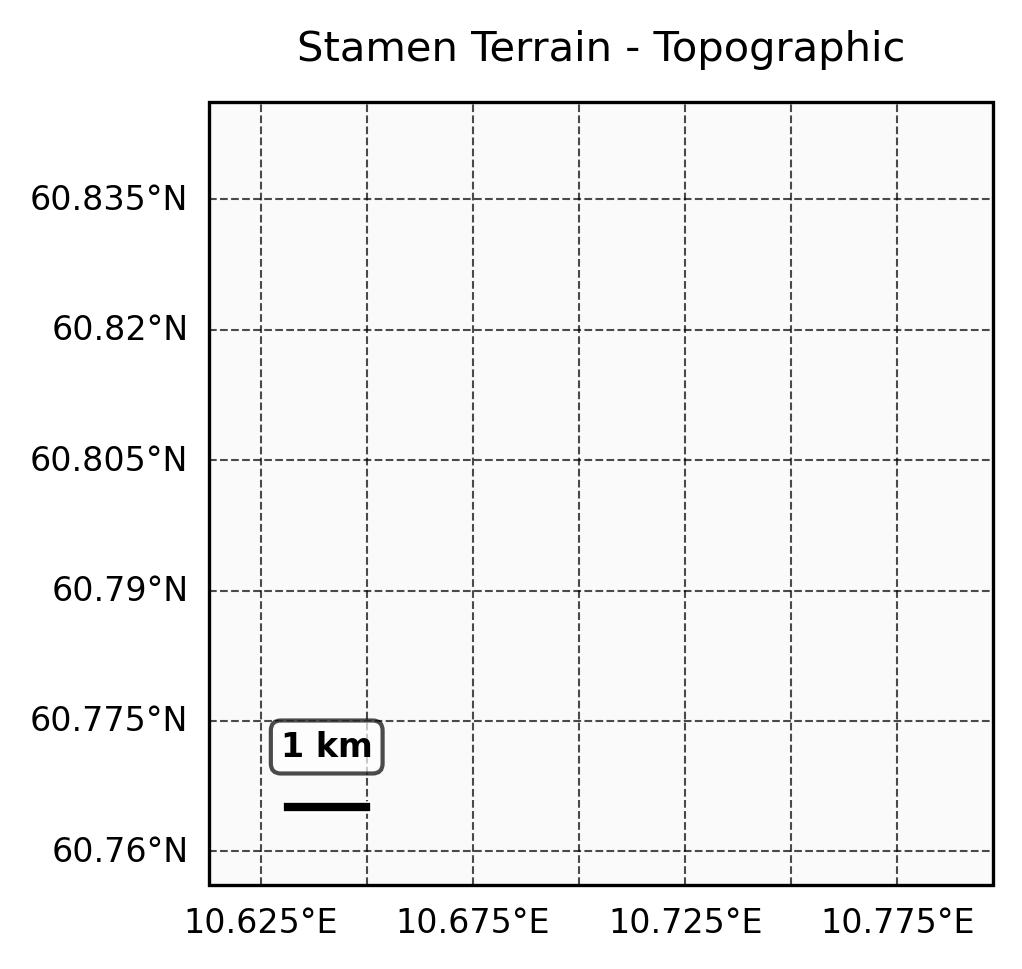

In [ ]:
# Option 2: Stamen Terrain - topographic style
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = cimgt.Stamen("terrain-background")
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_image(tile_source, 15)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    color="black",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
)

plt.title("Stamen Terrain - Topographic", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

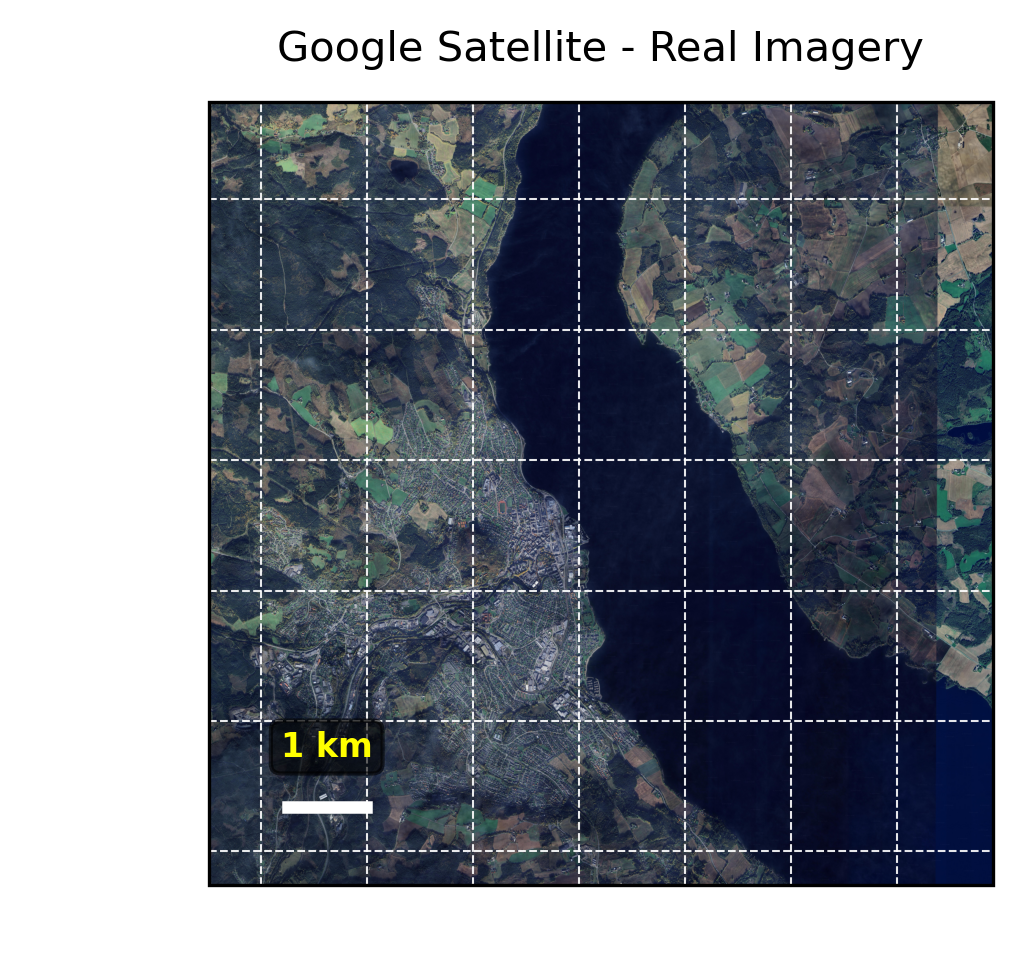

In [ ]:
# Option 3: Google Tiles (satellite imagery)
class GoogleTiles(cimgt.GoogleWTS):
    def _image_url(self, tile):
        x, y, z = tile
        url = f"https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"
        return url


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = GoogleTiles()
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_image(tile_source, 16)  # Higher zoom for satellite

# Add gridlines (white for satellite)
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="white", alpha=0.9, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8, "color": "white"}
gl.ylabel_style = {"size": 8, "color": "white"}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "w-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    color="yellow",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.6),
)

plt.title("Google Satellite - Real Imagery", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## Publication-Ready Offline Map (No Internet Required)
Clean, high-resolution map using only cartopy's built-in Natural Earth data

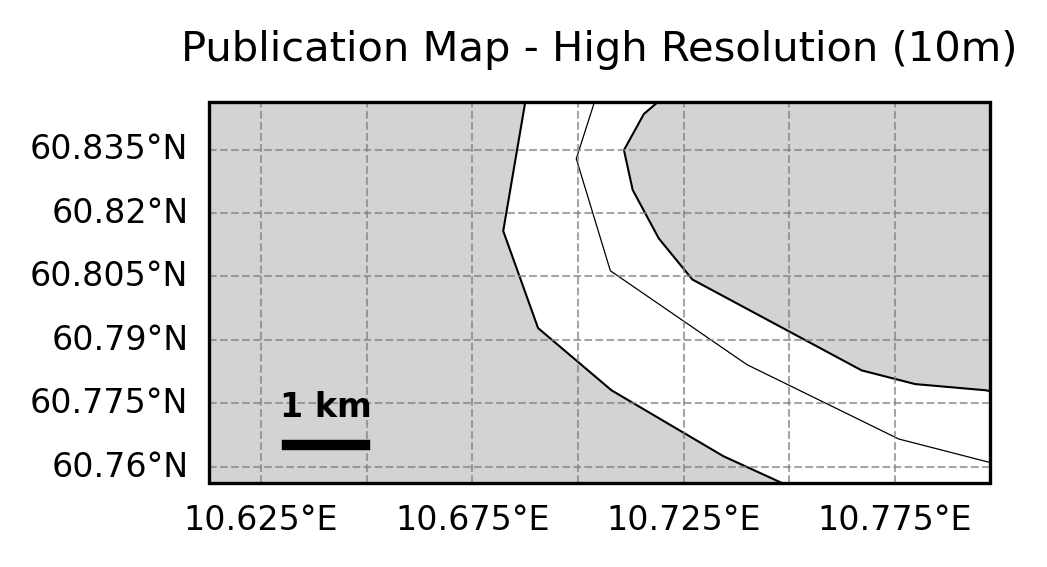

In [ ]:
# Clean publication map - all land same color, high resolution
# Uses Natural Earth 10m data (open source, offline, publication-quality)

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Single color land with detailed coastlines (10m = highest resolution)
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.8,
)

# Water features
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")

ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="white",
    edgecolor="black",
    linewidth=0.5,
)

# Add rivers for context
ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="black", linewidth=0.3)

# Clean gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.title("Publication Map - High Resolution (10m)", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

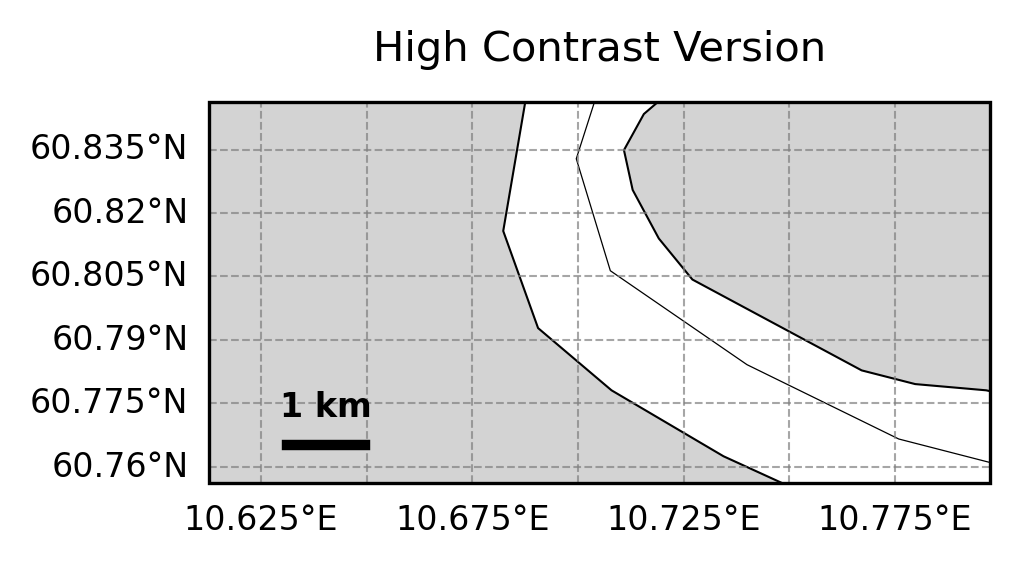

In [ ]:
# Alternative: Darker land for better contrast
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Darker gray land
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="#D3D3D3",  # Darker gray
    edgecolor="black",
    linewidth=0.8,
)

ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white")

ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="white",
    edgecolor="black",
    linewidth=0.5,
)

ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="black", linewidth=0.3)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.title("High Contrast Version", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

✓ Saved: mjosa_sampling_site_5km.pdf
  Resolution: 300 DPI
  Format: PDF
  Data source: Natural Earth 10m (open source, CC0 license)


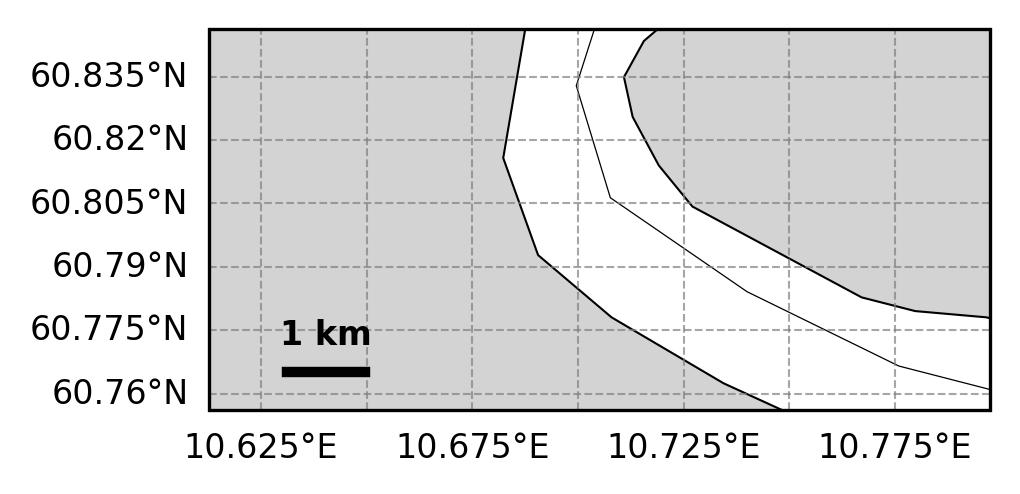

In [ ]:
# Export final publication version
# Set parameters and run this cell to save

FINAL_EXTENT_KM = 5  # Choose zoom level (2 for 4x4 km, 5 for 10x10 km, etc.)
LAND_COLOR = "lightgray"  # or '#D3D3D3' for darker, or 'wheat', '#E0E0E0'
OUTPUT_FORMAT = (
    "pdf"  # 'pdf' recommended for publications (vector), or 'png', 'svg', 'tiff'
)
OUTPUT_DPI = 300

# Calculate extent
lat_span = FINAL_EXTENT_KM / km_per_deg_lat
lon_span = FINAL_EXTENT_KM / km_per_deg_lon
final_extent = [
    LON_CENTER - lon_span,
    LON_CENTER + lon_span,
    LAT_CENTER - lat_span,
    LAT_CENTER + lat_span,
]

# Create figure
fig = plt.figure(figsize=(3.5, 3.5), dpi=OUTPUT_DPI)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(final_extent, crs=ccrs.PlateCarree())

# Add features (10m = highest resolution Natural Earth data)
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor=LAND_COLOR,
    edgecolor="black",
    linewidth=0.8,
)

ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white")

ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="white",
    edgecolor="black",
    linewidth=0.5,
)

ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="black", linewidth=0.3)

# Gridlines with coordinates
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = final_extent[0] + 0.1 * (final_extent[1] - final_extent[0])
scale_y = final_extent[2] + 0.1 * (final_extent[3] - final_extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.tight_layout()

# Save
output_file = f"mjosa_sampling_site_{FINAL_EXTENT_KM}km.{OUTPUT_FORMAT}"
plt.savefig(output_file, dpi=OUTPUT_DPI, bbox_inches="tight", facecolor="white")
print(f"✓ Saved: {output_file}")
print(f"  Resolution: {OUTPUT_DPI} DPI")
print(f"  Format: {OUTPUT_FORMAT.upper()}")
print(f"  Data source: Natural Earth 10m (open source, CC0 license)")
plt.show()

## BEST OPTION: High-Res Stamen Toner Lite (Clean, No Labels)
Stamen Toner Lite provides clean land outlines without street names - perfect for publications

c:\conda_envs\my_env\lib\site-packages\cartopy\io\img_tiles.py:414: UserWarning: The Stamen styles are no longer served by Stamen and are now served by Stadia Maps. Please use the StadiaMapsTiles class instead.
  warnings.warn("The Stamen styles are no longer served by Stamen and "


<urlopen error [Errno 11001] getaddrinfo failed><urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>

<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errno 11001] getaddrinfo failed>
<urlopen error [Errn

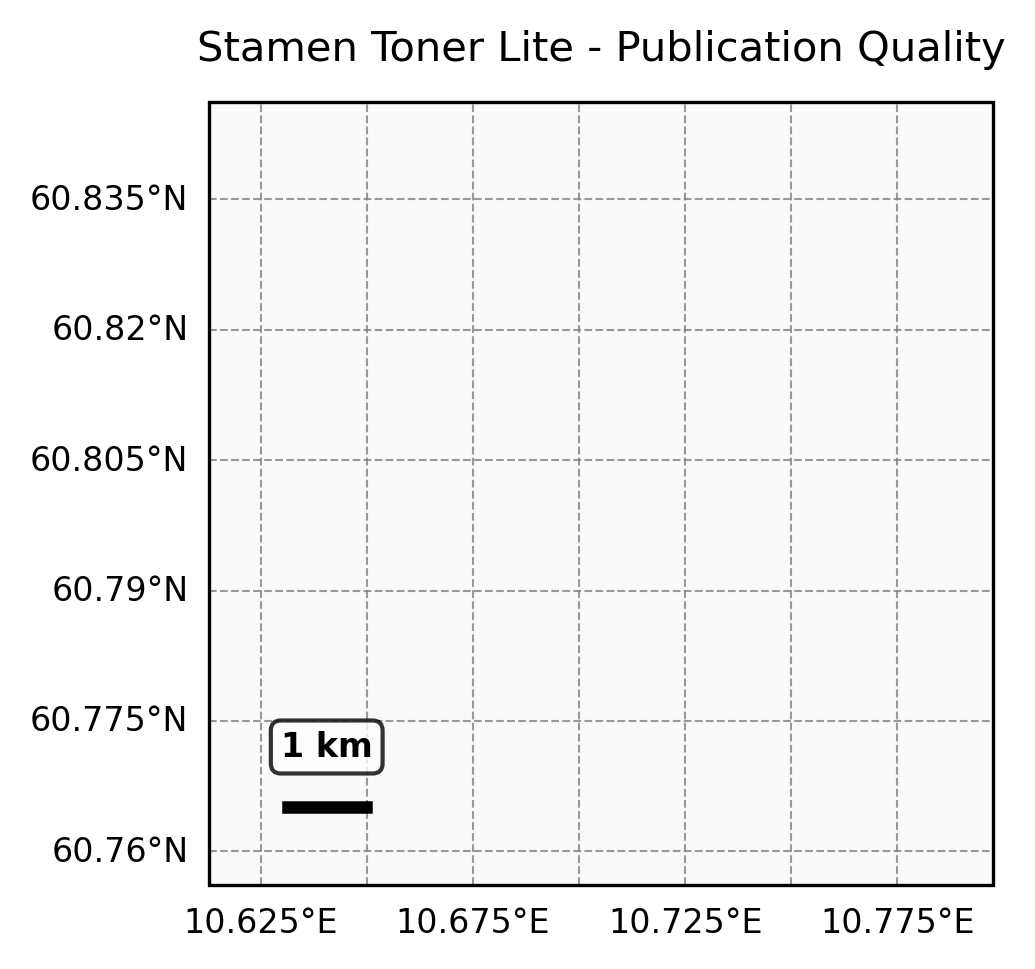

✓ Stamen Toner Lite: Clean B&W map, no labels, high detail
  License: CC BY 3.0 (open source, attribution required)
  Resolution: ~2-5 meters at this zoom level


In [ ]:
# Stamen Toner Lite - Clean black/white map with detailed coastlines, NO labels
# This is MUCH higher resolution than Natural Earth 10m data
# Open source (CC BY 3.0), suitable for publications

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
tile_source = cimgt.Stamen("toner-lite")  # 'toner-lite' = clean, no labels
ax = plt.axes(projection=tile_source.crs)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Zoom level 16 = ~1-5 meter resolution (very high detail)
ax.add_image(tile_source, 16)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.8, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=3,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

plt.title("Stamen Toner Lite - Publication Quality", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

print("✓ Stamen Toner Lite: Clean B&W map, no labels, high detail")
print("  License: CC BY 3.0 (open source, attribution required)")
print("  Resolution: ~2-5 meters at this zoom level")

## Option A: Natural Earth with Proper Attribution
Free to use, public domain equivalent, good for overview maps

In [ ]:
# Natural Earth 10m - Best available offline resolution
# License: Public domain equivalent, no attribution required (but can cite in Methods)

fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Background color
ax.set_facecolor("white")

# Add features in order: ocean, land, lakes
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="lightblue", zorder=0)
ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.8,
    zorder=1,
)
ax.add_feature(
    cfeature.LAKES.with_scale("10m"),
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.5,
    zorder=2,
)
ax.add_feature(
    cfeature.RIVERS.with_scale("10m"), edgecolor="blue", linewidth=0.3, zorder=2
)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot(
    [scale_x, scale_x + scale_lon],
    [scale_y, scale_y],
    "k-",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.text(
    scale_x + scale_lon / 2,
    scale_y + 0.005,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=8,
    transform=ccrs.PlateCarree(),
    weight="bold",
)

plt.title("Natural Earth 10m (Public Domain)", fontsize=10, pad=10)
plt.tight_layout()
plt.show()

print("Data source: Natural Earth 10m")
print("License: Public domain equivalent")
print("Attribution: Optional (can cite naturalearthdata.com in Methods)")

## Option B: Kartverket N50 (Highest Detail for Norway)
Best accuracy for Norwegian lakes/coastlines - requires download from data.norge.no

In [ ]:
# Download instructions for Kartverket N50:
# 1. Go to: https://kartkatalog.geonorge.no/metadata/n50-kartdata/ea192681-d039-42ec-b1bc-f3ce04c189ac
# 2. Download "N50 Kartdata" (GeoPackage or Shapefile format)
# 3. Extract water polygons layer (Vann / Water)
# 4. Save path below

# Example code (uncomment and edit path when you have the data):
"""
import geopandas as gpd

# Load Kartverket N50 water polygons
kartverket_water = gpd.read_file("path/to/N50_Vann.gpkg", layer="vann")
kartverket_water = kartverket_water.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=300)
ax.set_facecolor('lightgray')  # Land color

# Clip to extent
kartverket_water_clip = kartverket_water.cx[extent[0]:extent[1], extent[2]:extent[3]]

# Plot water
kartverket_water_clip.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)

# Set extent
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Add gridlines (manual for matplotlib axes)
ax.grid(True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
ax.set_xlabel('Longitude (°E)', fontsize=8)
ax.set_ylabel('Latitude (°N)', fontsize=8)
ax.tick_params(labelsize=8)

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot([scale_x, scale_x + scale_lon], [scale_y, scale_y], 'k-', linewidth=2.5)
ax.text(scale_x + scale_lon/2, scale_y + 0.005, f'{scale_km} km',
        ha='center', va='bottom', fontsize=8, weight='bold')

plt.title('Kartverket N50 (High Detail Norway)', fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('kartverket_map.pdf')
plt.show()

print("Data source: Kartverket N50 Kartdata")
print("License: Open data (Norge digitalt)")
print("Attribution: 'Data from Kartverket' in caption or methods")
"""

print("⚠ Kartverket N50 requires manual download")
print(
    "📥 Download from: https://kartkatalog.geonorge.no/metadata/n50-kartdata/ea192681-d039-42ec-b1bc-f3ce04c189ac"
)
print("📁 Look for water polygons layer (Vann)")
print("✏️ Uncomment code above and set file path")

## Option C: HydroLAKES (Global Lake Database)
High-accuracy lake polygons, CC BY 4.0 license (attribution required)

In [ ]:
# Download instructions for HydroLAKES:
# 1. Go to: https://www.hydrosheds.org/products/hydrolakes
# 2. Register and download HydroLAKES database
# 3. Extract Lake Mjøsa polygon (by name or coordinates)

# Example code (uncomment when you have the data):
"""
import geopandas as gpd

# Load HydroLAKES
hydrolakes = gpd.read_file("path/to/HydroLAKES.shp")
hydrolakes = hydrolakes.to_crs("EPSG:4326")

# Find Lake Mjøsa (by name or bounding box)
mjosa = hydrolakes[hydrolakes['Lake_name'] == 'Mjøsa']  # or use spatial filter

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=300)
ax.set_facecolor('lightgray')  # Land

# Plot Mjøsa
mjosa.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.grid(True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
ax.set_xlabel('Longitude (°E)', fontsize=8)
ax.set_ylabel('Latitude (°N)', fontsize=8)

# Scale bar
scale_km = 1
scale_lon = scale_km / km_per_deg_lon
scale_x = extent[0] + 0.1 * (extent[1] - extent[0])
scale_y = extent[2] + 0.1 * (extent[3] - extent[2])
ax.plot([scale_x, scale_x + scale_lon], [scale_y, scale_y], 'k-', linewidth=2.5)
ax.text(scale_x + scale_lon/2, scale_y + 0.005, f'{scale_km} km',
        ha='center', va='bottom', fontsize=8, weight='bold')

plt.title('HydroLAKES - Lake Mjøsa', fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('hydrolakes_map.pdf')
plt.show()

print("Data source: HydroLAKES")
print("License: CC BY 4.0")
print("Attribution REQUIRED: 'HydroLAKES (Messager et al., 2016)' in caption")
"""

print("⚠ HydroLAKES requires registration and download")
print("📥 Download from: https://www.hydrosheds.org/products/hydrolakes")
print("📄 License: CC BY 4.0 - MUST attribute in caption")
print("✏️ Uncomment code above and set file path")

## Summary: Which Option to Use?

| Option | Resolution | License | Attribution | Best For |
|--------|-----------|---------|-------------|----------|
| **Natural Earth 10m** | ~10m accuracy | Public domain | Optional | Quick overview maps |
| **Kartverket N50** | ~1m accuracy | Open data | Credit Kartverket | Detailed Norway maps |
| **HydroLAKES** | High accuracy lakes | CC BY 4.0 | **Required** | Lake-focused studies |
| **OSM tiles** | Very high | ODbL | **Required** | Online maps only |